In [480]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import importlib
import model.model
import model.grid
import model
importlib.reload(model.model)
importlib.reload(model.utils)
importlib.reload(model.grid)

from model.model import QGM
from model.utils import Solver 
from model.grid import Grid

jax.config.update("jax_platform_name", "cpu")

# === Parameter definitions === #
master_key = jax.random.PRNGKey(0)
master_key, key_init, init1, init2 = jax.random.split(master_key, num=4)

params = {
        'nx': 256, 
        'Lx': 2*jnp.pi, 
        'beta': 10, 
        'k_beta':1.5, #for now we're just doing this for the forcing range idgaf
        'eta': 10, 
        'mu': 1e-4,
        'nu': 1e-8,
        'dt': 1e-2,
        'k_f': 16.0,        # central forcing wavenumber
        'k_width': 1.5,    # width of the ring
        'epsilon': 1e-5,   #energy input 
        'key':key_init
}

# === Set up model === 
model = QGM(params) 
model.initialize()

Number of NaNs (black squares) at step 50: 0


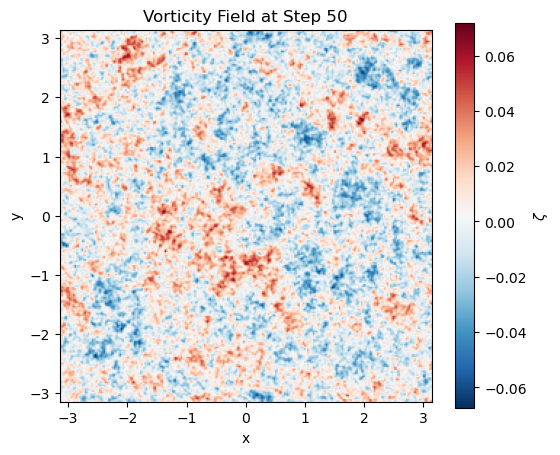

In [481]:
model.initialize()
model.plot_field_at_step(50)

In [482]:
model.initialize()
model.make_animation(nsteps=10000, frame_interval=100, outname="outputs/qg.gif")